In [2]:

import joblib
print(joblib.__version__)

1.5.3


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/telco_churn.csv")
print(df.shape)
df.head()
df.info


(7043, 21)


<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL 

In [4]:
from pathlib import Path
FIG = Path("../reports/figures")
FIG.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

def save(name):
    plt.tight_layout()
    plt.savefig(FIG / name, dpi=150, bbox_inches="tight")
    plt.show() 


In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df["Churn"] = (df["Churn"] == "Yes").astype(int)
df = df.drop(columns=["customerID"])

In [6]:
from pathlib import Path
FIG = Path("../reports/figures")
FIG.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

def save(name):
    plt.tight_layout()
    plt.savefig(FIG / name, dpi=150, bbox_inches="tight")
    plt.show()

In [7]:
print(FIG.resolve())

C:\Users\rawen\Desktop\churn-java\python\reports\figures


In [8]:
from sklearn.model_selection import train_test_split

X = pd.get_dummies(df.drop(columns=["Churn"]), drop_first=True)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(5634, 30) (1409, 30)


In [9]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
)
model.fit(X_train, y_train)

proba = model.predict_proba(X_test)[:, 1]
print("AUC:", round(roc_auc_score(y_test, proba), 3))
print(classification_report(y_test, proba > 0.5))

AUC: 0.84
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



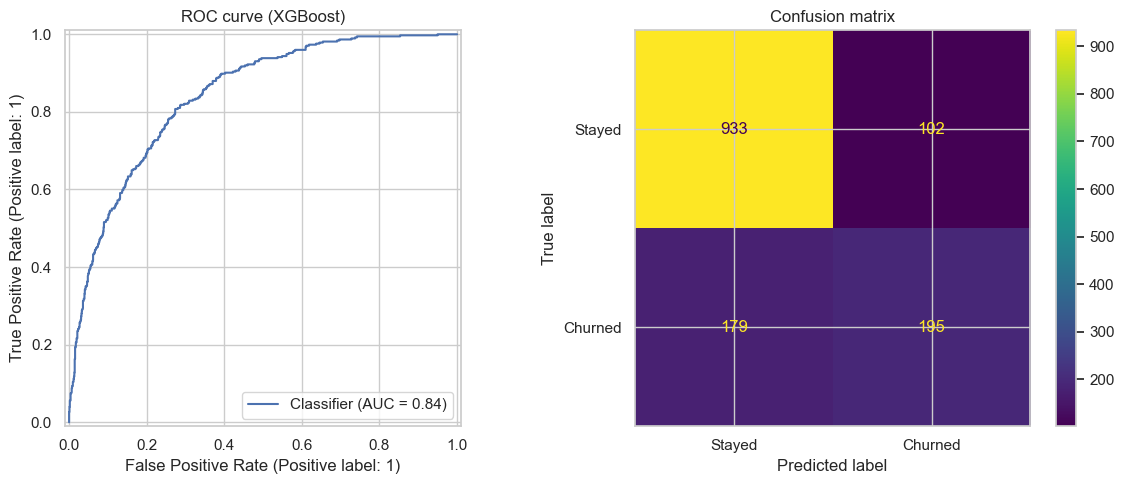

In [10]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_test, proba, ax=axes[0])
axes[0].set_title("ROC curve (XGBoost)")
ConfusionMatrixDisplay.from_predictions(
    y_test, proba > 0.5, display_labels=["Stayed", "Churned"], ax=axes[1]
)
axes[1].set_title("Confusion matrix")
save("05_model_evaluation.png")

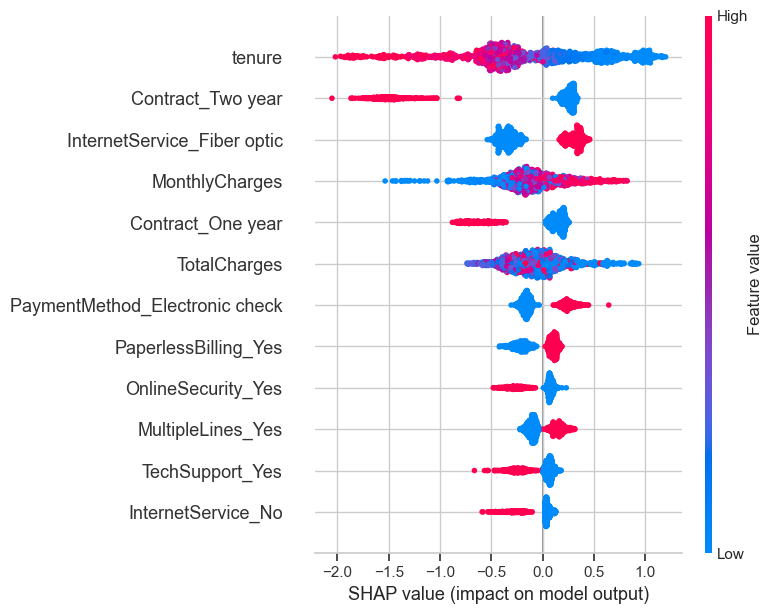

In [11]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False, max_display=12)
save("06_shap_summary.png")

In [12]:
import joblib

joblib.dump(model, "../src/model.joblib")
joblib.dump(list(X.columns), "../src/columns.joblib")
print("saved")

saved


In [13]:
from sklearn.metrics import precision_score, recall_score

for t in [0.5, 0.4, 0.3, 0.25]:
    pred = proba > t
    print(f"threshold {t}: recall {recall_score(y_test, pred):.2f}, "
          f"precision {precision_score(y_test, pred):.2f}, flagged {pred.sum()}")

threshold 0.5: recall 0.52, precision 0.66, flagged 297
threshold 0.4: recall 0.65, precision 0.59, flagged 412
threshold 0.3: recall 0.75, precision 0.53, flagged 534
threshold 0.25: recall 0.81, precision 0.51, flagged 591


In [14]:
import sqlite3

conn = sqlite3.connect("../data/churn.db")
raw = pd.read_csv("../data/telco_churn.csv")
raw.to_sql("customers", conn, if_exists="replace", index=False)
print(pd.read_sql("SELECT COUNT(*) AS n FROM customers", conn))

      n
0  7043


In [15]:
from pathlib import Path

queries = Path("../sql/churn_analysis.sql").read_text().split(";")
for q in queries:
    if q.strip():
        display(pd.read_sql(q, conn))
        

,Contract,customers,churn_pct
0,Month-to-month,3875,42.7
1,One year,1473,11.3
2,Two year,1695,2.8


,tenure_group,customers,churn_pct
0,0-12 months,2186,47.4
1,13-36 months,1856,25.5
2,37+ months,3001,11.9


,Contract,annual_revenue_lost
0,Month-to-month,1450165.0
1,One year,169421.0
2,Two year,49984.0


In [16]:
print(conn.execute("SELECT name FROM sqlite_master").fetchall())

[('customers',)]


In [17]:
from sklearn.metrics import precision_score, recall_score

for t in [0.5, 0.4, 0.3, 0.25]:
    pred = proba > t
    print(f"threshold {t}: recall {recall_score(y_test, pred):.2f}, "
          f"precision {precision_score(y_test, pred):.2f}, flagged {pred.sum()}")

threshold 0.5: recall 0.52, precision 0.66, flagged 297
threshold 0.4: recall 0.65, precision 0.59, flagged 412
threshold 0.3: recall 0.75, precision 0.53, flagged 534
threshold 0.25: recall 0.81, precision 0.51, flagged 591


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
logreg.fit(X_train, y_train)
auc_lr = roc_auc_score(y_test, logreg.predict_proba(X_test)[:, 1])
print("Logistic Regression AUC:", round(auc_lr, 3))

cv = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
print("XGBoost 5-fold AUC:", round(cv.mean(), 3), "+/-", round(cv.std(), 3))

Logistic Regression AUC: 0.842
XGBoost 5-fold AUC: 0.842 +/- 0.011


In [19]:
avg_annual = df["MonthlyCharges"].mean() * 12
t = 0.3                                   # your chosen threshold
caught = int(((proba > t) & (y_test == 1)).sum())
saved = caught * 0.30                     # assumption: 30% of caught churners are retained
print(f"Caught churners: {caught}")
print(f"Revenue retained: about EUR {saved * avg_annual:,.0f} per year (test set only)")

Caught churners: 282
Revenue retained: about EUR 65,746 per year (test set only)


In [20]:
from pathlib import Path

export = df.copy()
export["ChurnProbability"] = model.predict_proba(X)[:, 1]
export["RiskLevel"] = pd.cut(export["ChurnProbability"], bins=[0, 0.3, 0.6, 1.0],
                             labels=["Low", "Medium", "High"], include_lowest=True)
export["ExpectedLoss"] = export["ChurnProbability"] * export["MonthlyCharges"] * 12

Path("../reports").mkdir(exist_ok=True)
export.to_csv("../reports/tableau_export.csv", index=False)
print(export.shape)

(7043, 23)


In [21]:
import joblib
joblib.dump(model, "../src/model.joblib")
joblib.dump(list(X.columns), "../src/columns.joblib")

['../src/columns.joblib']

In [22]:
from sklearn.metrics import precision_score, recall_score

for t in [0.5, 0.4, 0.3, 0.25]:
    pred = proba > t
    print(f"threshold {t}: recall {recall_score(y_test, pred):.2f}, "
          f"precision {precision_score(y_test, pred):.2f}, flagged {pred.sum()}")

threshold 0.5: recall 0.52, precision 0.66, flagged 297
threshold 0.4: recall 0.65, precision 0.59, flagged 412
threshold 0.3: recall 0.75, precision 0.53, flagged 534
threshold 0.25: recall 0.81, precision 0.51, flagged 591


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
logreg.fit(X_train, y_train)
print("Logistic Regression AUC:", round(roc_auc_score(y_test, logreg.predict_proba(X_test)[:, 1]), 3))

cv = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
print("XGBoost 5-fold AUC:", round(cv.mean(), 3))

Logistic Regression AUC: 0.842
XGBoost 5-fold AUC: 0.842


In [ ]:
cv_lr = cross_val_score(logreg, X, y, cv=5, scoring="roc_auc")
print("Logistic Regression 5-fold AUC:", round(cv_lr.mean(), 3))